## 3D Eikonal tomography example based on the Long Valley Caldera

@Author: Ettore Biondi - ettore88@stanford.edu

In this notebook we will apply an adjoint-state Eikonal tomography inversion workflow to obtain 3D structures from earthquake traveltime measurements. This example is based on the work by [Biondi et al. (2023)](https://www.science.org/doi/10.1126/sciadv.adi9878).

In [32]:
import numpy as np
import utm
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
fontsize=24
params = {
    'image.interpolation': 'nearest',
    'image.cmap': 'gray',
    'savefig.dpi': 300,  # to adjust notebook inline plot size
    'axes.labelsize': fontsize, # fontsize for x and y labels (was 10)
    'axes.titlesize': fontsize,
    'font.size': fontsize,
    'legend.fontsize': fontsize,
    'xtick.labelsize': fontsize,
    'ytick.labelsize': fontsize,
    "font.weight": 'bold',
    'text.usetex': False,
    "ytick.major.pad": 6.0,
    "xtick.major.pad": 6.0,
    "axes.labelweight": 'bold'
}
matplotlib.rcParams.update(params)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import sys
# Utility functions
sys.path.insert(0,"../Scripts/")
import utils
# import importlib
# importlib.reload(utils)

<module 'utils' from '/home/ebiondi/research/projects/LongValley/notebooks/ManuscriptFigures/Workshop/Notebooks/../Scripts/utils.py'>

In [20]:
(Vp, Vs,
 dy, dx, dz,
 ny, nx, nz,
 minLon, maxLon, minLat, maxLat,
 oy, ox, oz,
 zone_n, zone_lt,
 NLL_origin_utm
)=utils.load_velocity_model_npz("../Inputs/Initial3DVelLongValley.npz")

zAxis = np.linspace(oz, oz+(nz-1)*dz, nz)
latAxis = np.linspace(minLat, maxLat, ny)
lonAxis = np.linspace(minLon, maxLon, nx)

Let's plot the initial wave speed Vp and Vs models and place some geographical features to orient us. We will also plot the events considered in the inversion and the distirbuted acoustic sensing (DAS) channel locations.

In [3]:
with np.load("../Inputs/map_overlays.npz", allow_pickle=True) as f:
    craters = f["craters"]
    caldera  = f["caldera"]
    lakes   = f["lakes"]

In [4]:
with np.load("../Inputs/Source_Receiver_geometry.npz", allow_pickle=True) as f:
    SouPosLatLon = f["Sources"]
    RecPosLatLon = f["Receivers"]

In [5]:
# Let's also exctract some slices from the model
with np.load("../Inputs/SlicesCoord.npz", allow_pickle=True) as f:
    sliceLatLon1 = f["slice1"]
    sliceLatLon2 = f["slice2"]
AxSlice1 = utils.slide_def(sliceLatLon1[0,:], sliceLatLon1[1,:], NLL_origin_utm, zone_n, zone_lt)
AxSlice2 = utils.slide_def(sliceLatLon2[0,:], sliceLatLon2[1,:], NLL_origin_utm, zone_n, zone_lt)

# With topography
with np.load("../Inputs/LongValley_topography.npz", allow_pickle=True) as f:
    elevationTopo = f["elevation"]

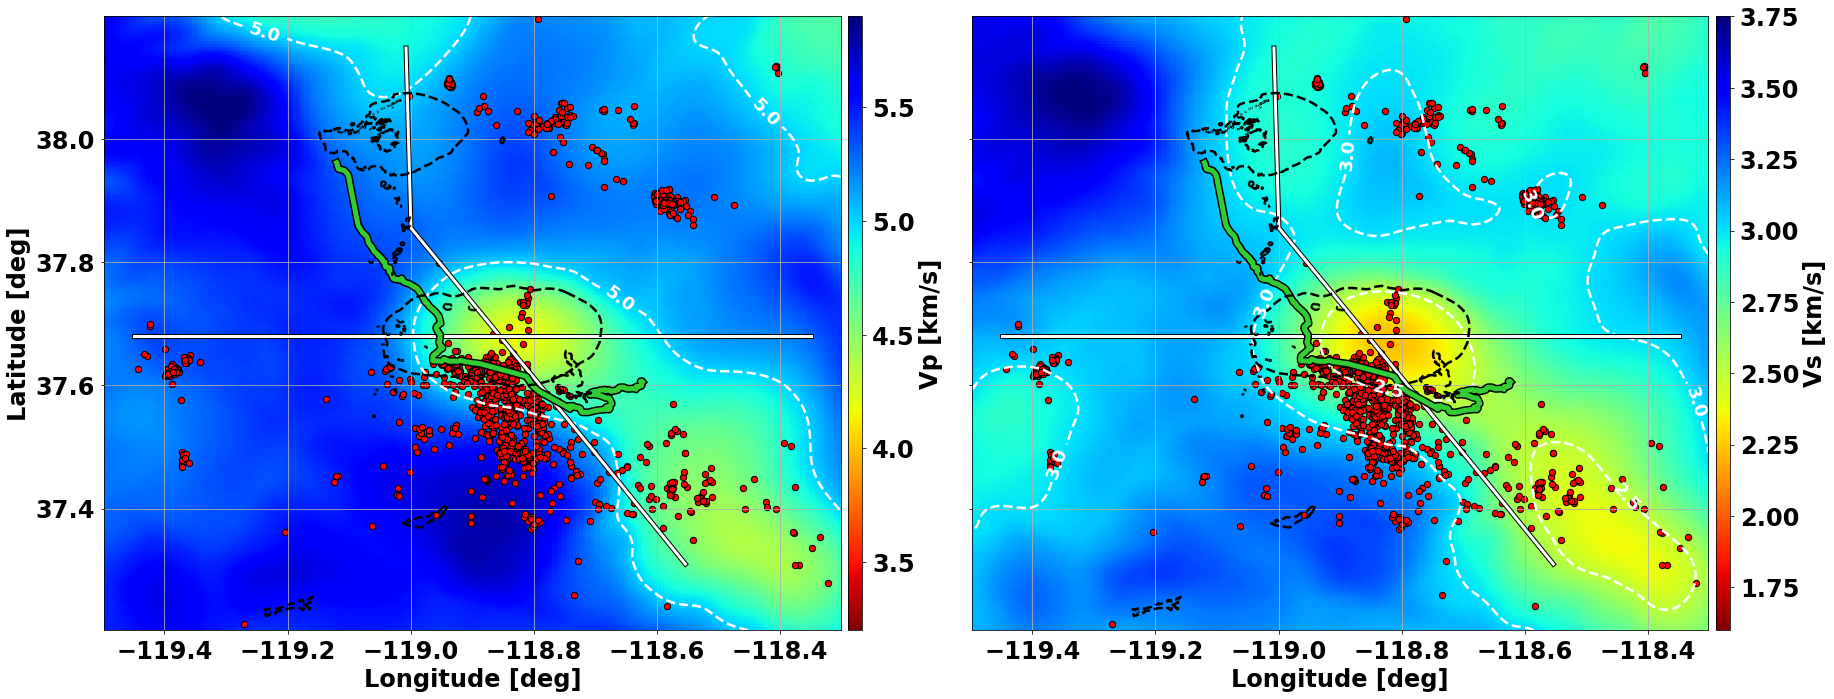

In [119]:
z_slice = -1.0  # km
idx_z = int(np.floor(((z_slice - oz) / dz) + 0.5))

Vs_slice = Vs[:, :, idx_z]
Vp_slice = Vp[:, :, idx_z]

fig, (axVp, axVs) = plt.subplots(1, 2, figsize=(26, 12), sharey=True)

# -------------------------
# VS 
# -------------------------
vmin_vs = 1.6
vmax_vs = 3.75

im_vs = axVs.imshow(
    Vs_slice, cmap="jet_r",
    extent=[minLon, maxLon, minLat, maxLat],
    origin="lower",
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice, levels=levels_vs,
    extent=[minLon, maxLon, minLat, maxLat],
    colors="white", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'k-',lw=5)
axVs.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'w-',lw=3)
axVs.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'k-',lw=5)
axVs.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'w-',lw=3)

# -------------------------
# VP 
# -------------------------
vmin_vp = 3.2
vmax_vp = 5.9

im_vp = axVp.imshow(
    Vp_slice, cmap="jet_r",
    extent=[minLon, maxLon, minLat, maxLat],
    origin="lower",
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [3.0, 5.0]   # example
cs_vp = axVp.contour(
    Vp_slice, levels=levels_vp,
    extent=[minLon, maxLon, minLat, maxLat],
    colors="white", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'k-',lw=5)
axVp.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'w-',lw=3)
axVp.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'k-',lw=5)
axVp.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'w-',lw=3)


# -------------------------
# COMMON OVERLAYS FUNCTION
# -------------------------
def plot_overlays(ax):
    ax.plot(RecPosLatLon[:,1], RecPosLatLon[:,0], "k-", lw=8)
    ax.plot(RecPosLatLon[:,1], RecPosLatLon[:,0], color="limegreen", lw=5)
    ax.plot(caldera[:,1], caldera[:,0], "k--", lw=2.5)
    for crater in craters:
        ax.plot(crater[:,1], crater[:,0], "k--", lw=2.5)
    for lake in lakes:
        ax.plot(lake[:,1], lake[:,0], "k--", lw=2.5)
    ax.scatter(SouPosLatLon[:,1], SouPosLatLon[:,0],
               s=40, c="r", edgecolors="black")

plot_overlays(axVs)
plot_overlays(axVp)

axVs.set_xlabel("Longitude [deg]")
axVp.set_xlabel("Longitude [deg]")
axVp.set_ylabel("Latitude [deg]")

for ax in (axVs, axVp):
    ax.set_xlim(minLon, maxLon)
    ax.set_ylim(minLat, maxLat)
    ax.grid()

# -------------------------
# COLORBARS
# -------------------------
div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=0.1)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=0.1)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

plt.tight_layout()
plt.show()

In [106]:
dzSlice=0.1
# South-West -> North slice
# Vp
eleSliceAA, zAxFineAA, Vp_sliceInitAA = utils.extract_profile(Vp, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon1[1,:], sliceLatLon1[0,:], dzSlice, elevationTopo)
# Vs
_, _, Vs_sliceInitAA = utils.extract_profile(Vs, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon1[1,:], sliceLatLon1[0,:], dzSlice, elevationTopo)

dzFineAA = zAxFineAA[1]-zAxFineAA[0]

# South-West -> North slice
# Vp
eleSliceBB, zAxFineBB, Vp_sliceInitBB = utils.extract_profile(Vp, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon2[1,:], sliceLatLon2[0,:], dzSlice, elevationTopo)
# Vs
_, _, Vs_sliceInitBB = utils.extract_profile(Vs, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon2[1,:], sliceLatLon2[0,:], dzSlice, elevationTopo)

dzFineBB = zAxFineBB[1]-zAxFineBB[0]

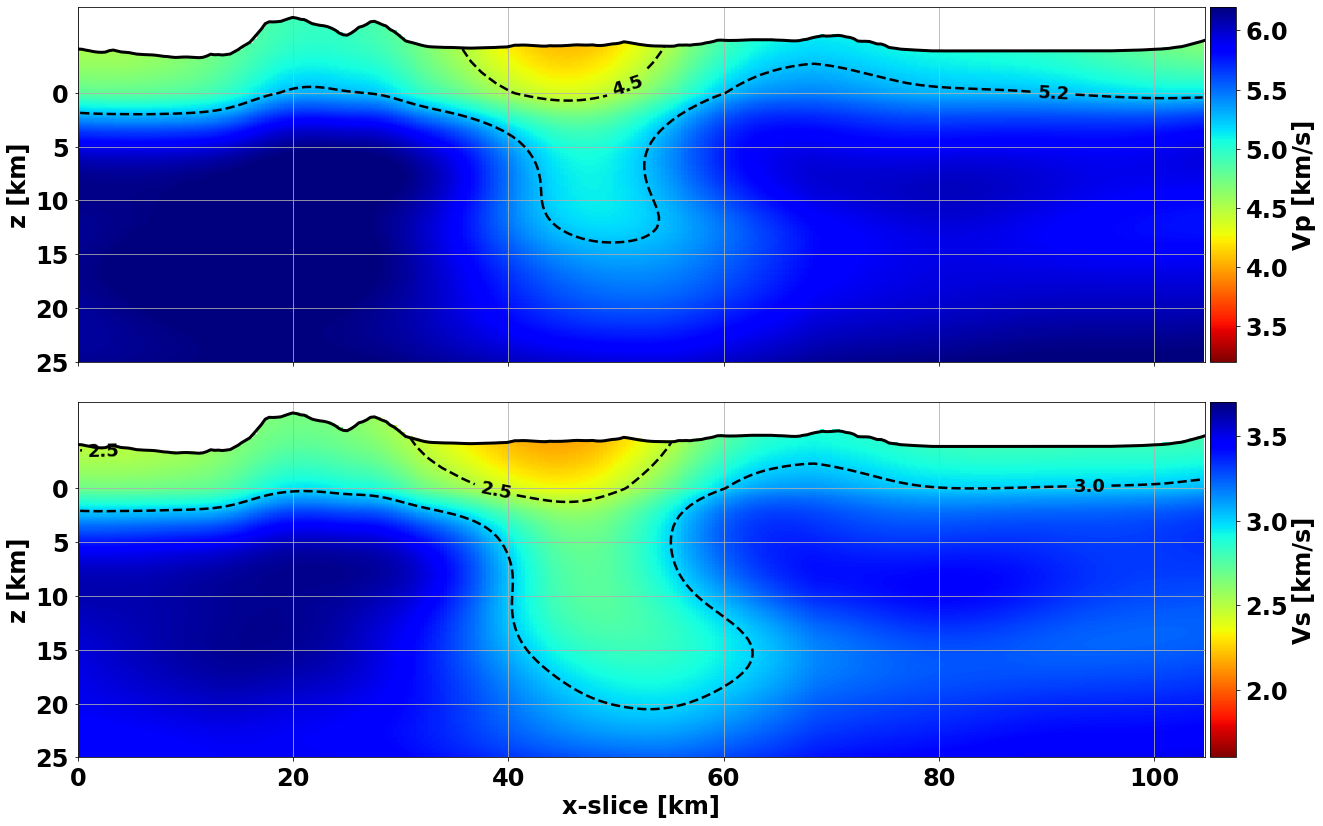

In [120]:
# -------------------------
# Common parameters
# -------------------------
min_x = AxSlice1[0]
max_x = AxSlice1[-1]

max_z = 25.0
idx_z = int(np.floor(((max_z - oz) / dzFineAA) + 0.5))

Vp_slice = Vp_sliceInitAA[:, :idx_z]
Vs_slice = Vs_sliceInitAA[:, :idx_z]

# Color limits
vmin_vp = 3.2
vmax_vp = 6.2
vmin_vs = 1.6
vmax_vs = 3.7

extent = [AxSlice1[0], AxSlice1[-1],
          zAxFineAA[idx_z], zAxFineAA[0]]

# -------------------------
# Figure
# -------------------------
fig, (axVp, axVs) = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# ==========================================================
# VS 
# ==========================================================
im_vs = axVs.imshow(
    Vs_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice.T, levels=levels_vs,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(AxSlice1, eleSliceAA, c="k", lw=3)
axVs.set_ylabel("z [km]")
axVs.set_ylim(max_z, eleSliceAA.min() - 0.5)
axVs.set_yscale('function', functions=(utils.forward, utils.inverse))
axVs.grid()

div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=-1.0)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

# ==========================================================
# VP 
# ==========================================================
im_vp = axVp.imshow(
    Vp_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [4.5, 5.25]
cs_vp = axVp.contour(
    Vp_slice.T, levels=levels_vp,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(AxSlice1, eleSliceAA, c="k", lw=3)
axVs.set_xlabel("x-slice [km]")
axVp.set_ylabel("z [km]")
axVp.set_ylim(max_z, eleSliceAA.min() - 0.5)
axVp.set_yscale('function', functions=(utils.forward, utils.inverse))
axVp.grid()

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=-1.0)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

# -------------------------
plt.tight_layout()
plt.show()

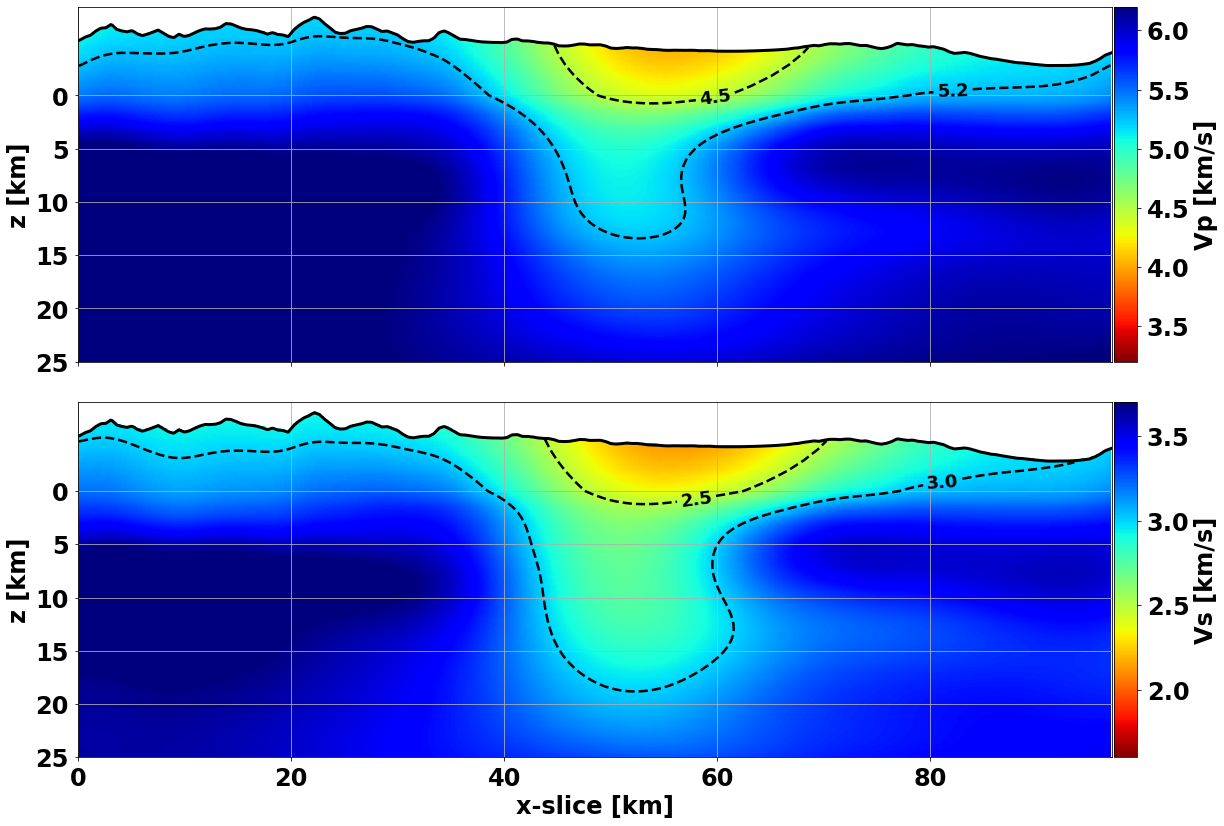

In [121]:
# -------------------------
# Common parameters
# -------------------------
min_x = AxSlice2[0]
max_x = AxSlice2[-1]

max_z = 25.0
idx_z = int(np.floor(((max_z - oz) / dzFineBB) + 0.5))

Vp_slice = Vp_sliceInitBB[:, :idx_z]
Vs_slice = Vs_sliceInitBB[:, :idx_z]

# Color limits
vmin_vp = 3.2
vmax_vp = 6.2
vmin_vs = 1.6
vmax_vs = 3.7

extent = [AxSlice2[0], AxSlice2[-1],
          zAxFineBB[idx_z], zAxFineBB[0]]

# -------------------------
# Figure
# -------------------------
fig, (axVp, axVs) = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# ==========================================================
# VS 
# ==========================================================
im_vs = axVs.imshow(
    Vs_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice.T, levels=levels_vs,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(AxSlice2, eleSliceBB, c="k", lw=3)
axVs.set_ylabel("z [km]")
axVs.set_ylim(max_z, eleSliceBB.min() - 0.5)
axVs.set_yscale('function', functions=(utils.forward, utils.inverse))
axVs.grid()

div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=-1.0)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

# ==========================================================
# VP 
# ==========================================================
im_vp = axVp.imshow(
    Vp_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [4.5, 5.25]
cs_vp = axVp.contour(
    Vp_slice.T, levels=levels_vp,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(AxSlice2, eleSliceBB, c="k", lw=3)
axVs.set_xlabel("x-slice [km]")
axVp.set_ylabel("z [km]")
axVp.set_ylim(max_z, eleSliceBB.min() - 0.5)
axVp.set_yscale('function', functions=(utils.forward, utils.inverse))
axVp.grid()

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=-1.0)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

# -------------------------
plt.tight_layout()
plt.show()


Let's load the observed traveltimes and try to plot them against the estimated traveltimes using the initial model.

In [67]:
# Eikonal Tomography module
import sys
pyEikoTomo = "../Scripts/"
sys.path.insert(0,pyEikoTomo)
pySolver = "../Scripts/python-solver/GenericSolver/python/"
sys.path.insert(0,pySolver)

In [68]:
import EikonalTomography3DMod
import pyVector

In [69]:
with np.load("../Inputs/LongValley_obs_traveltimes.npz", allow_pickle=True) as f:
    P_TT = f["P_TT"]
    S_TT = f["S_TT"]

In [70]:
# Downsampling sources to reduce computational cost
downsampleSource = 10

rec_x, rec_y = (np.array(utm.from_latlon(RecPosLatLon[:,0],RecPosLatLon[:,1],zone_n,zone_lt)[:2])
                -np.expand_dims(NLL_origin_utm[:2],axis=1))*1e-3
events_x, events_y = (np.array(utm.from_latlon(SouPosLatLon[::downsampleSource,0],SouPosLatLon[::downsampleSource,1],zone_n,zone_lt)[:2])
                      -np.expand_dims(NLL_origin_utm[:2],axis=1))*1e-3
# Source and receiver geometry arrays
RecGeo = np.array([rec_x,rec_y,RecPosLatLon[:,2]]).T
SouGeo = np.array([events_x,events_y,SouPosLatLon[::downsampleSource,2]]).T

# Downsampling observed traveltimes
P_TT = P_TT[::downsampleSource, :]
S_TT = S_TT[::downsampleSource, :]

In [71]:
nshot = P_TT.shape[0]
nrec = P_TT.shape[1]

In [72]:
velVec = np.zeros((2,ny,nx,nz), dtype=np.float32)
TTinit = np.zeros((SouGeo.shape[0]*2,RecGeo.shape[0]), dtype=np.float32)
velVec[0,:,:,:] = Vp.astype(np.float32)
velVec[1,:,:,:] = Vs.astype(np.float32) 

In [73]:
# Modeling vectors
VelInit = pyVector.vectorIC(velVec)
TTinit = pyVector.vectorIC(TTinit)
# Modeling and linearized operators
Eiko3D_op = EikonalTomography3DMod.EikonalTT_3D(VelInit, TTobs, 0.0, 0.0, oz, dy, dx, dz, 
                                                SouGeo, RecGeo, verbose=True, allocateTT=False, ginsu=False)

In [74]:
Eiko3D_op.forward(False, VelInit, TTinit)

[Parallel(n_jobs=40)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 146 out of 146 | elapsed:   53.0s finished
[Parallel(n_jobs=40)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 146 out of 146 | elapsed:   49.2s finished


In [75]:
P_TT_init = TTinit.getNdArray()[:nshot,:]
S_TT_init = TTinit.getNdArray()[nshot:,:]

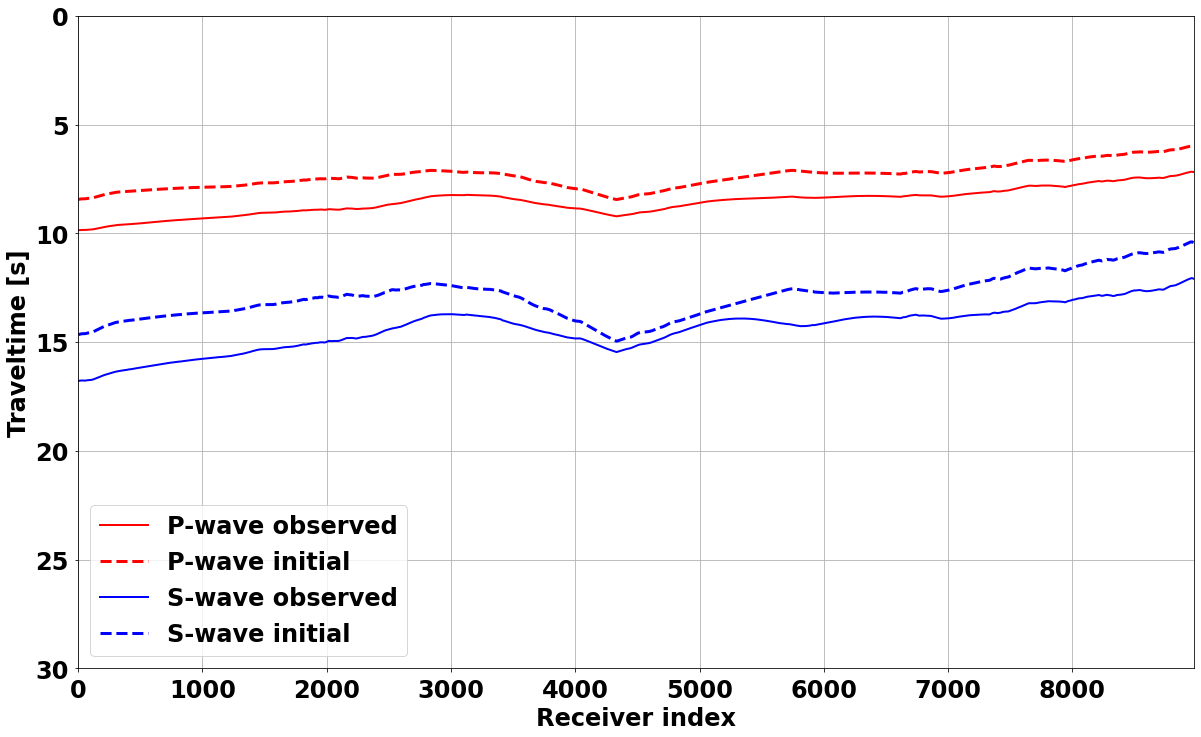

In [86]:
ishot = 44
fig, ax = plt.subplots(figsize=(20,12))
ax.plot(P_TT[ishot,:], "r-", lw=2, label="P-wave observed")
ax.plot(P_TT_init[ishot,:], "r--", lw=3, label="P-wave initial")

ax.plot(S_TT[ishot,:], "b-", lw=2, label="S-wave observed")
ax.plot(S_TT_init[ishot,:], "b--", lw=3, label="S-wave initial")
ax.legend()

ax.set_ylim(30.0,0.0)
ax.set_xlim(0,nrec)

ax.set_ylabel("Traveltime [s]")
ax.set_xlabel("Receiver index")
ax.grid()


Let's try to run a few iterations of a 3D Eikonal tomography simple workflow to improve the velocity model.

In [87]:
TTobs = TTinit.clone()
TTobs.getNdArray()[:nshot, :] = P_TT
TTobs.getNdArray()[nshot:, :] = S_TT

In [93]:
# instantiate solver
from pyNonLinearSolver import LBFGSsolver as LBFGS
from pyNpOperator import GaussianFilter
import pyOperator as pyOp
from pyProblem import ProblemL2NonLinear
from pyStopper import BasicStopper
BFGSsolver = LBFGS(BasicStopper(niter=5, tolg_proj=1e-32), m_steps=30)
# Saving objective function
BFGSsolver.setDefaults(save_obj=True)

# Creating problem object using Smoothing filter
G = GaussianFilter(VelInit, 5.0)

Eiko3D_op = EikonalTomography3DMod.EikonalTT_3D(VelInit, TTobs, 0.0, 0.0, oz, dy, dx, dz, 
                                                SouGeo, RecGeo, verbose=False, allocateTT=False, ginsu=False)
Eiko3D_Lin_Op = EikonalTomography3DMod.EikonalTT_lin_3D(VelInit, TTobs, 0.0, 0.0, oz, dy, dx, dz, 
                                                SouGeo, RecGeo, verbose=False, ginsu=False)

Eik3D_Inv_NlOp = pyOp.NonLinearOperator(Eiko3D_op, Eiko3D_Lin_Op * G, Eiko3D_Lin_Op.set_vel)

L2_tt_prob = ProblemL2NonLinear(VelInit.clone(), TTobs, Eik3D_Inv_NlOp)

In [94]:
BFGSsolver.run(L2_tt_prob, verbose=True)

##########################################################################################
Limited-memory Broyden-Fletcher-Goldfarb-Shanno (L-BFGS) algorithm 
Maximum number of steps to be used for Hessian inverse estimation: 30 
Restart folder: /net/han/ssd-tmp-nobak3/ebiondi/scratch/restart_2026-02-01T10-21-25.732442/
##########################################################################################

iter = 0, obj = 3.74355e+05, resnorm = 8.65e+02, gradnorm = 4.02e+03, feval = 1, geval = 1
iter = 1, obj = 1.36231e+05, resnorm = 5.22e+02, gradnorm = 2.70e+03, feval = 2, geval = 2
iter = 2, obj = 9.25606e+04, resnorm = 4.30e+02, gradnorm = 1.35e+03, feval = 4, geval = 4
iter = 3, obj = 7.36213e+04, resnorm = 3.84e+02, gradnorm = 1.10e+03, feval = 5, geval = 5
iter = 4, obj = 5.96622e+04, resnorm = 3.45e+02, gradnorm = 4.62e+02, feval = 6, geval = 6
iter = 5, obj = 5.13685e+04, resnorm = 3.21e+02, gradnorm = 2.46e+02, feval = 7, geval = 7
Terminate: maximum number of iterations 

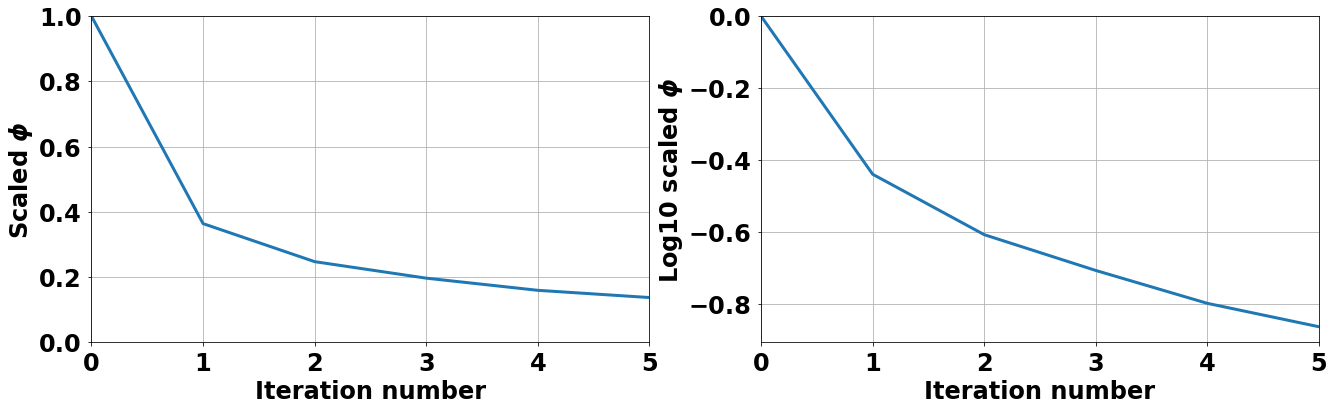

In [96]:
objVal = BFGSsolver.obj
fig = plt.figure(figsize=(22,6))
ax = plt.subplot(121)
plt.plot(objVal/objVal[0],lw=3)
ax.set_xlabel("Iteration number")
ax.set_ylabel("Scaled $\phi$")
ax.set_ylim([0,1])
ax.grid()
ax.autoscale(enable=True, axis='x', tight=True)
ax = plt.subplot(122)
ax.plot(np.log10(objVal/objVal[0]), lw=3)
ax.set_xlabel("Iteration number")
ax.set_ylabel("Log10 scaled $\phi$")
ax.set_ylim([None,0])
ax.grid()
ax.autoscale(enable=True, axis='x', tight=True)

In [100]:
InvModel = L2_tt_prob.get_model()
VpInv = InvModel.getNdArray()[0,:]
VsInv = InvModel.getNdArray()[1,:]

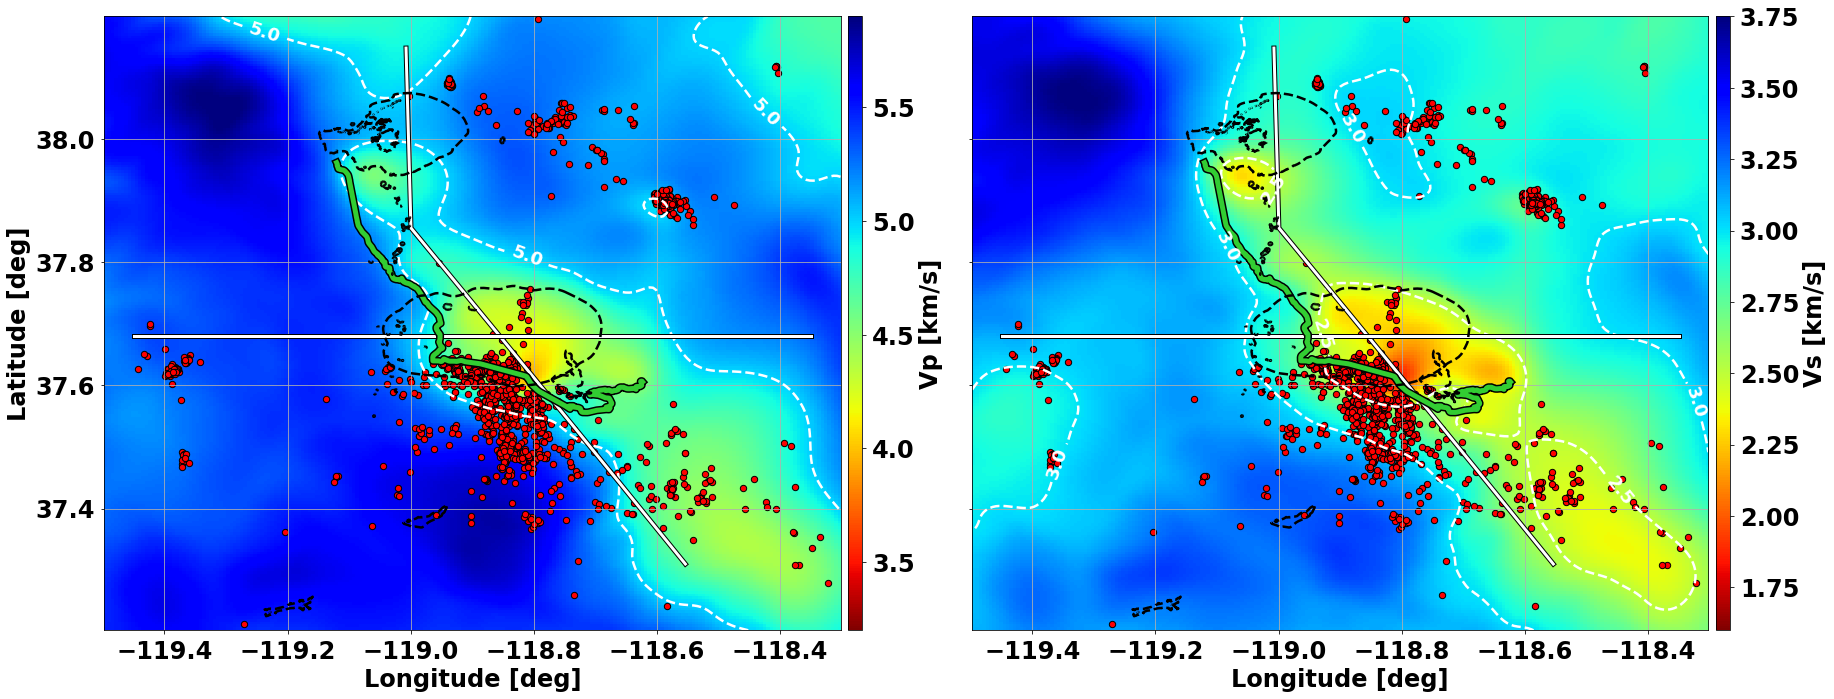

In [118]:
z_slice = -1.0  # km
idx_z = int(np.floor(((z_slice - oz) / dz) + 0.5))

Vs_slice = VsInv[:, :, idx_z]
Vp_slice = VpInv[:, :, idx_z]

fig, (axVp, axVs) = plt.subplots(1, 2, figsize=(26, 12), sharey=True)

# -------------------------
# VS 
# -------------------------
vmin_vs = 1.6
vmax_vs = 3.75

im_vs = axVs.imshow(
    Vs_slice, cmap="jet_r",
    extent=[minLon, maxLon, minLat, maxLat],
    origin="lower",
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice, levels=levels_vs,
    extent=[minLon, maxLon, minLat, maxLat],
    colors="white", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'k-',lw=5)
axVs.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'w-',lw=3)
axVs.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'k-',lw=5)
axVs.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'w-',lw=3)

# -------------------------
# VP 
# -------------------------
vmin_vp = 3.2
vmax_vp = 5.9

im_vp = axVp.imshow(
    Vp_slice, cmap="jet_r",
    extent=[minLon, maxLon, minLat, maxLat],
    origin="lower",
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [3.0, 5.0]   # example
cs_vp = axVp.contour(
    Vp_slice, levels=levels_vp,
    extent=[minLon, maxLon, minLat, maxLat],
    colors="white", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'k-',lw=5)
axVp.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'w-',lw=3)
axVp.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'k-',lw=5)
axVp.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'w-',lw=3)


# -------------------------
# COMMON OVERLAYS FUNCTION
# -------------------------
def plot_overlays(ax):
    ax.plot(RecPosLatLon[:,1], RecPosLatLon[:,0], "k-", lw=8)
    ax.plot(RecPosLatLon[:,1], RecPosLatLon[:,0], color="limegreen", lw=5)
    ax.plot(caldera[:,1], caldera[:,0], "k--", lw=2.5)
    for crater in craters:
        ax.plot(crater[:,1], crater[:,0], "k--", lw=2.5)
    for lake in lakes:
        ax.plot(lake[:,1], lake[:,0], "k--", lw=2.5)
    ax.scatter(SouPosLatLon[:,1], SouPosLatLon[:,0],
               s=40, c="r", edgecolors="black")

plot_overlays(axVs)
plot_overlays(axVp)

axVs.set_xlabel("Longitude [deg]")
axVp.set_xlabel("Longitude [deg]")
axVp.set_ylabel("Latitude [deg]")

for ax in (axVs, axVp):
    ax.set_xlim(minLon, maxLon)
    ax.set_ylim(minLat, maxLat)
    ax.grid()

# -------------------------
# COLORBARS
# -------------------------
div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=0.1)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=0.1)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

plt.tight_layout()
plt.show()

In [108]:
# South-West -> North slice
# Vp
_, _, Vp_sliceInvAA = utils.extract_profile(VpInv, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon1[1,:], sliceLatLon1[0,:], dzSlice, elevationTopo)
# Vs
_, _, Vs_sliceInvAA = utils.extract_profile(VsInv, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon1[1,:], sliceLatLon1[0,:], dzSlice, elevationTopo)


# South-West -> North slice
# Vp
_, _, Vp_sliceInvBB = utils.extract_profile(VpInv, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon2[1,:], sliceLatLon2[0,:], dzSlice, elevationTopo)
# Vs
_, _, Vs_sliceInvBB = utils.extract_profile(VsInv, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon2[1,:], sliceLatLon2[0,:], dzSlice, elevationTopo)


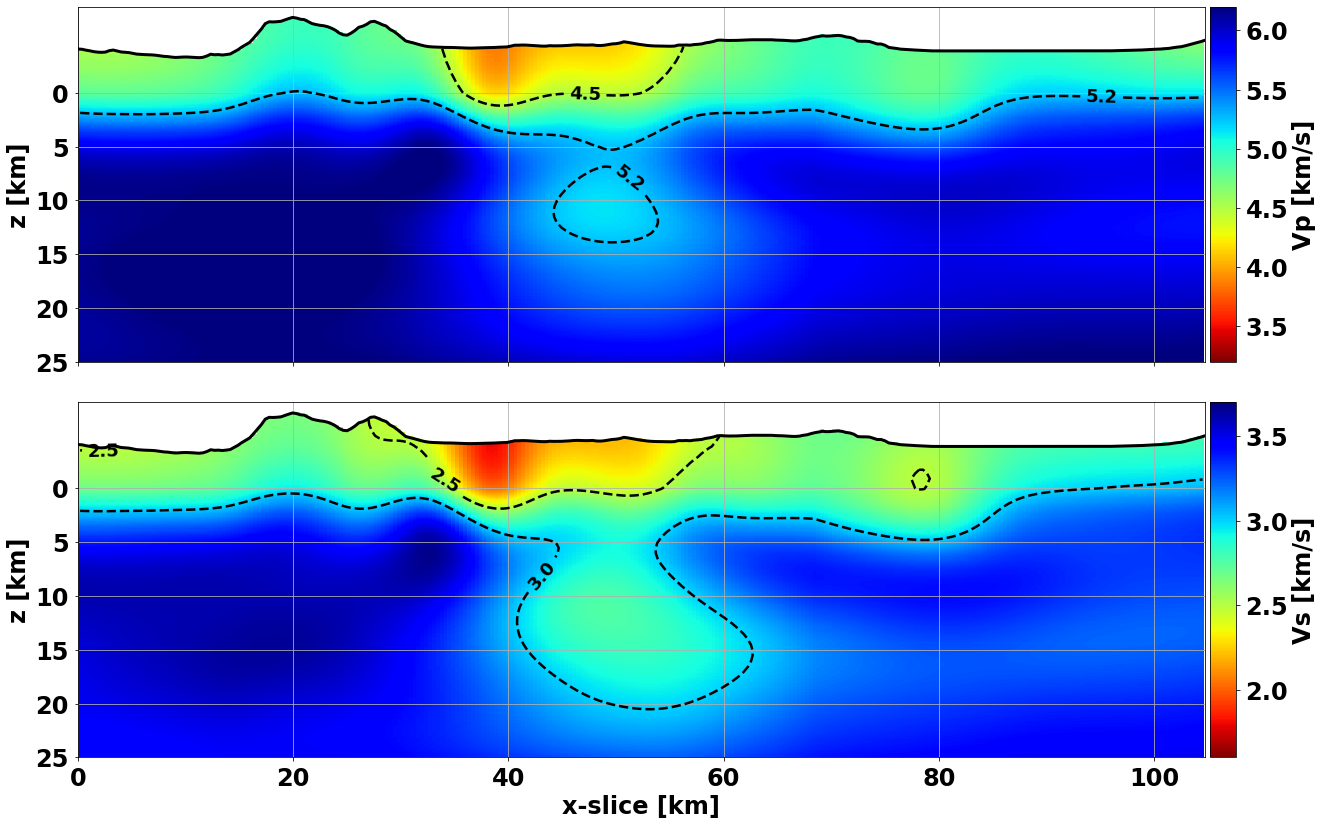

In [122]:
# -------------------------
# Common parameters
# -------------------------
min_x = AxSlice1[0]
max_x = AxSlice1[-1]

max_z = 25.0
idx_z = int(np.floor(((max_z - oz) / dzFineAA) + 0.5))

Vp_slice = Vp_sliceInvAA[:, :idx_z]
Vs_slice = Vs_sliceInvAA[:, :idx_z]

# Color limits
vmin_vp = 3.2
vmax_vp = 6.2
vmin_vs = 1.6
vmax_vs = 3.7

extent = [AxSlice1[0], AxSlice1[-1],
          zAxFineAA[idx_z], zAxFineAA[0]]

# -------------------------
# Figure
# -------------------------
fig, (axVp, axVs) = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# ==========================================================
# VS 
# ==========================================================
im_vs = axVs.imshow(
    Vs_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice.T, levels=levels_vs,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(AxSlice1, eleSliceAA, c="k", lw=3)
axVs.set_ylabel("z [km]")
axVs.set_ylim(max_z, eleSliceAA.min() - 0.5)
axVs.set_yscale('function', functions=(utils.forward, utils.inverse))
axVs.grid()

div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=-1.0)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

# ==========================================================
# VP 
# ==========================================================
im_vp = axVp.imshow(
    Vp_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [4.5, 5.25]
cs_vp = axVp.contour(
    Vp_slice.T, levels=levels_vp,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(AxSlice1, eleSliceAA, c="k", lw=3)
axVs.set_xlabel("x-slice [km]")
axVp.set_ylabel("z [km]")
axVp.set_ylim(max_z, eleSliceAA.min() - 0.5)
axVp.set_yscale('function', functions=(utils.forward, utils.inverse))
axVp.grid()

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=-1.0)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

# -------------------------
plt.tight_layout()
plt.show()

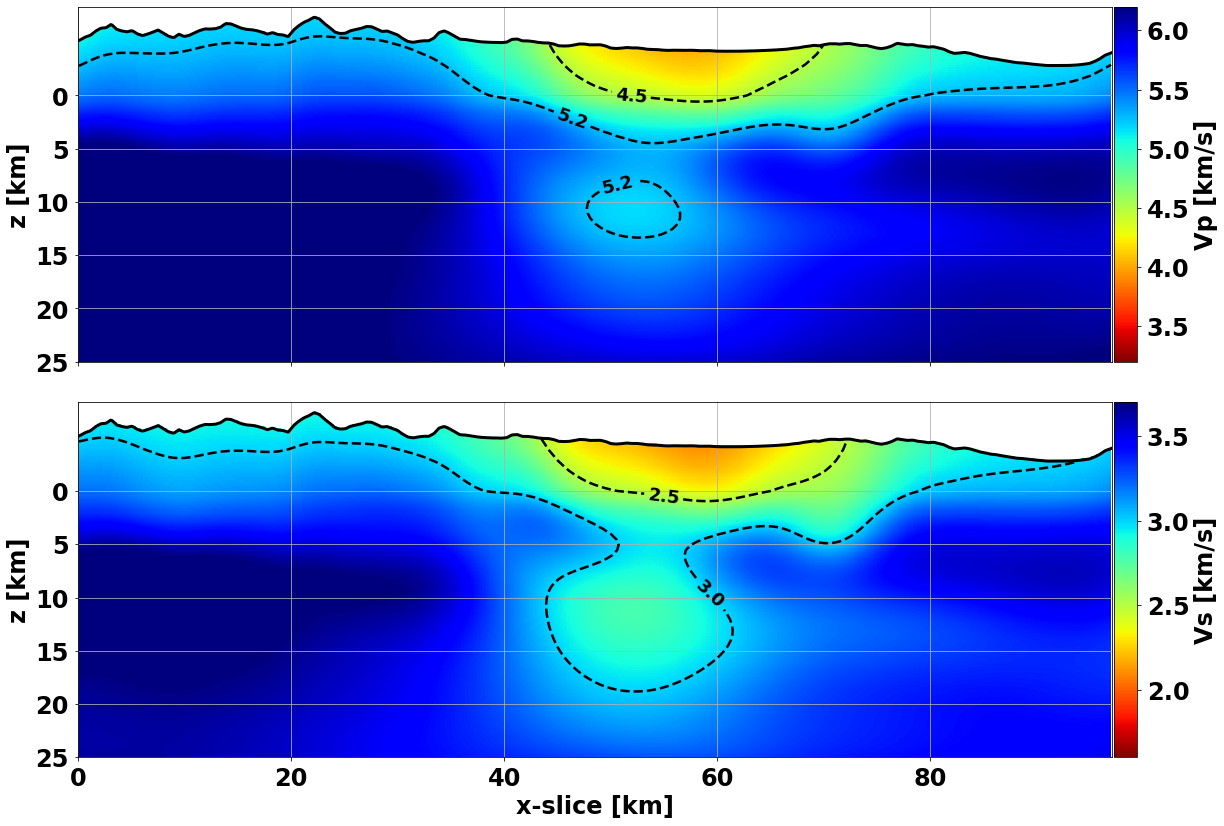

In [123]:
# -------------------------
# Common parameters
# -------------------------
min_x = AxSlice2[0]
max_x = AxSlice2[-1]

max_z = 25.0
idx_z = int(np.floor(((max_z - oz) / dzFineBB) + 0.5))

Vp_slice = Vp_sliceInvBB[:, :idx_z]
Vs_slice = Vs_sliceInvBB[:, :idx_z]

# Color limits
vmin_vp = 3.2
vmax_vp = 6.2
vmin_vs = 1.6
vmax_vs = 3.7

extent = [AxSlice2[0], AxSlice2[-1],
          zAxFineBB[idx_z], zAxFineBB[0]]

# -------------------------
# Figure
# -------------------------
fig, (axVp, axVs) = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# ==========================================================
# VS 
# ==========================================================
im_vs = axVs.imshow(
    Vs_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice.T, levels=levels_vs,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(AxSlice2, eleSliceBB, c="k", lw=3)
axVs.set_ylabel("z [km]")
axVs.set_ylim(max_z, eleSliceBB.min() - 0.5)
axVs.set_yscale('function', functions=(utils.forward, utils.inverse))
axVs.grid()

div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=-1.0)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

# ==========================================================
# VP 
# ==========================================================
im_vp = axVp.imshow(
    Vp_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [4.5, 5.25]
cs_vp = axVp.contour(
    Vp_slice.T, levels=levels_vp,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(AxSlice2, eleSliceBB, c="k", lw=3)
axVs.set_xlabel("x-slice [km]")
axVp.set_ylabel("z [km]")
axVp.set_ylim(max_z, eleSliceBB.min() - 0.5)
axVp.set_yscale('function', functions=(utils.forward, utils.inverse))
axVp.grid()

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=-1.0)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

# -------------------------
plt.tight_layout()
plt.show()


Let's plot the velocity models from the full study.

In [112]:
(Vp_final, Vs_final,
 _, _, _,
 _, _, _,
 _, _, _, _,
 _, _, _,
 _, _,
 _
)=utils.load_velocity_model_npz("../Inputs/Biondietal2023_3DVelLongValley.npz")


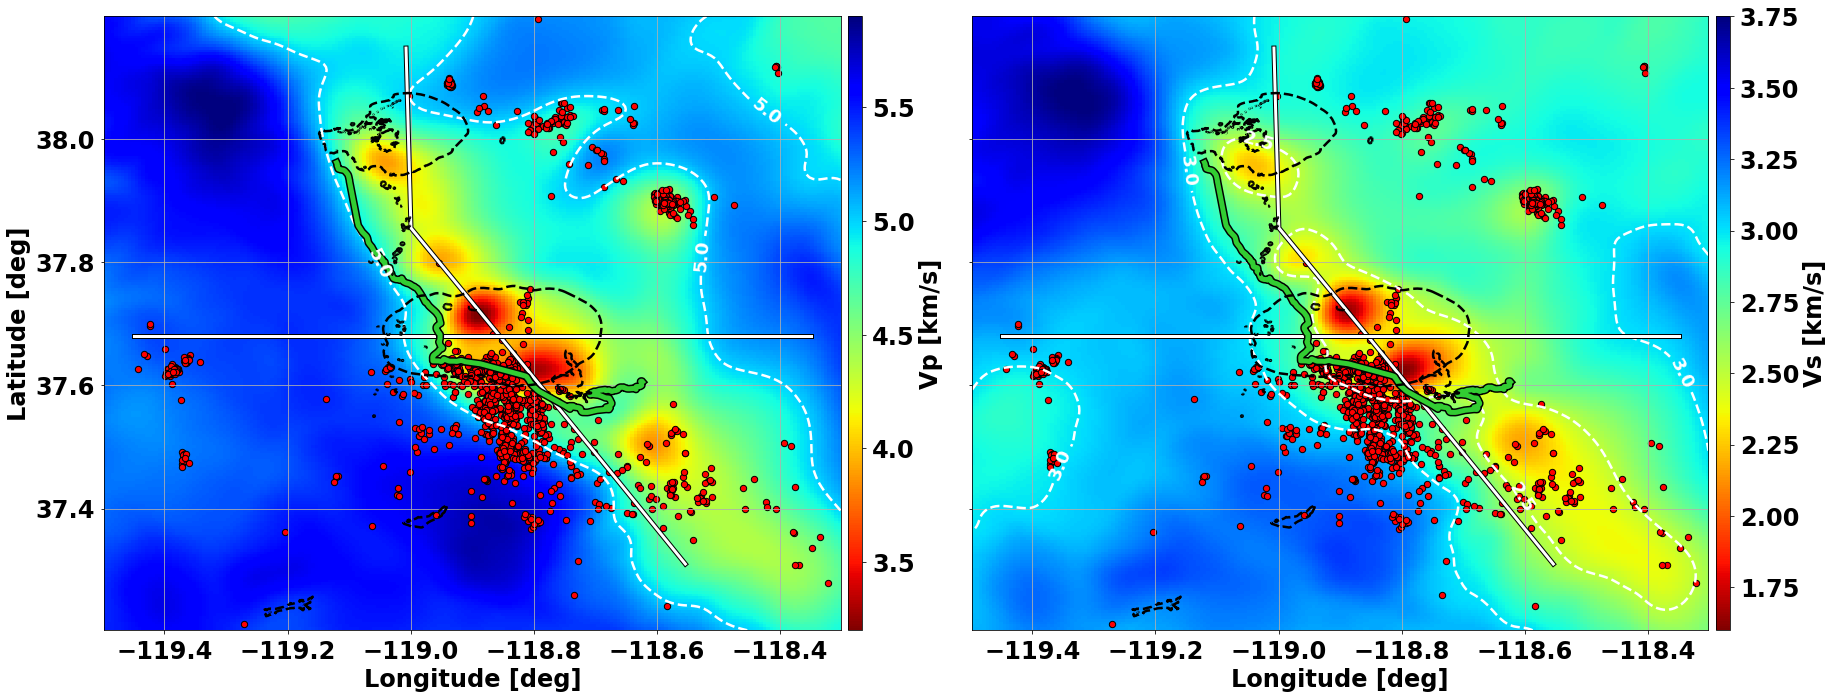

In [117]:
z_slice = -1.0  # km
idx_z = int(np.floor(((z_slice - oz) / dz) + 0.5))

Vs_slice = Vs_final[:, :, idx_z]
Vp_slice = Vp_final[:, :, idx_z]

fig, (axVp, axVs) = plt.subplots(1, 2, figsize=(26, 12), sharey=True)

# -------------------------
# VS 
# -------------------------
vmin_vs = 1.6
vmax_vs = 3.75

im_vs = axVs.imshow(
    Vs_slice, cmap="jet_r",
    extent=[minLon, maxLon, minLat, maxLat],
    origin="lower",
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice, levels=levels_vs,
    extent=[minLon, maxLon, minLat, maxLat],
    colors="white", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'k-',lw=5)
axVs.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'w-',lw=3)
axVs.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'k-',lw=5)
axVs.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'w-',lw=3)

# -------------------------
# VP 
# -------------------------
vmin_vp = 3.2
vmax_vp = 5.9

im_vp = axVp.imshow(
    Vp_slice, cmap="jet_r",
    extent=[minLon, maxLon, minLat, maxLat],
    origin="lower",
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [3.0, 5.0]   # example
cs_vp = axVp.contour(
    Vp_slice, levels=levels_vp,
    extent=[minLon, maxLon, minLat, maxLat],
    colors="white", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'k-',lw=5)
axVp.plot(sliceLatLon1[1,:],sliceLatLon1[0,:],'w-',lw=3)
axVp.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'k-',lw=5)
axVp.plot(sliceLatLon2[1,:],sliceLatLon2[0,:],'w-',lw=3)


# -------------------------
# COMMON OVERLAYS FUNCTION
# -------------------------
def plot_overlays(ax):
    ax.plot(RecPosLatLon[:,1], RecPosLatLon[:,0], "k-", lw=8)
    ax.plot(RecPosLatLon[:,1], RecPosLatLon[:,0], color="limegreen", lw=5)
    ax.plot(caldera[:,1], caldera[:,0], "k--", lw=2.5)
    for crater in craters:
        ax.plot(crater[:,1], crater[:,0], "k--", lw=2.5)
    for lake in lakes:
        ax.plot(lake[:,1], lake[:,0], "k--", lw=2.5)
    ax.scatter(SouPosLatLon[:,1], SouPosLatLon[:,0],
               s=40, c="r", edgecolors="black")

plot_overlays(axVs)
plot_overlays(axVp)

axVs.set_xlabel("Longitude [deg]")
axVp.set_xlabel("Longitude [deg]")
axVp.set_ylabel("Latitude [deg]")

for ax in (axVs, axVp):
    ax.set_xlim(minLon, maxLon)
    ax.set_ylim(minLat, maxLat)
    ax.grid()

# -------------------------
# COLORBARS
# -------------------------
div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=0.1)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=0.1)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

plt.tight_layout()
plt.show()

In [127]:
# South-West -> North slice
# Vp
_, _, Vp_sliceFinalAA = utils.extract_profile(Vp_final, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon1[1,:], sliceLatLon1[0,:], dzSlice, elevationTopo)
# Vs
_, _, Vs_sliceFinalAA = utils.extract_profile(Vs_final, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon1[1,:], sliceLatLon1[0,:], dzSlice, elevationTopo)


# South-West -> North slice
# Vp
_, _, Vp_sliceFinalBB = utils.extract_profile(Vp_final, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon2[1,:], sliceLatLon2[0,:], dzSlice, elevationTopo)
# Vs
_, _, Vs_sliceFinalBB = utils.extract_profile(Vs_final, lonAxis, latAxis, zAxis, 
                                                  sliceLatLon2[1,:], sliceLatLon2[0,:], dzSlice, elevationTopo)


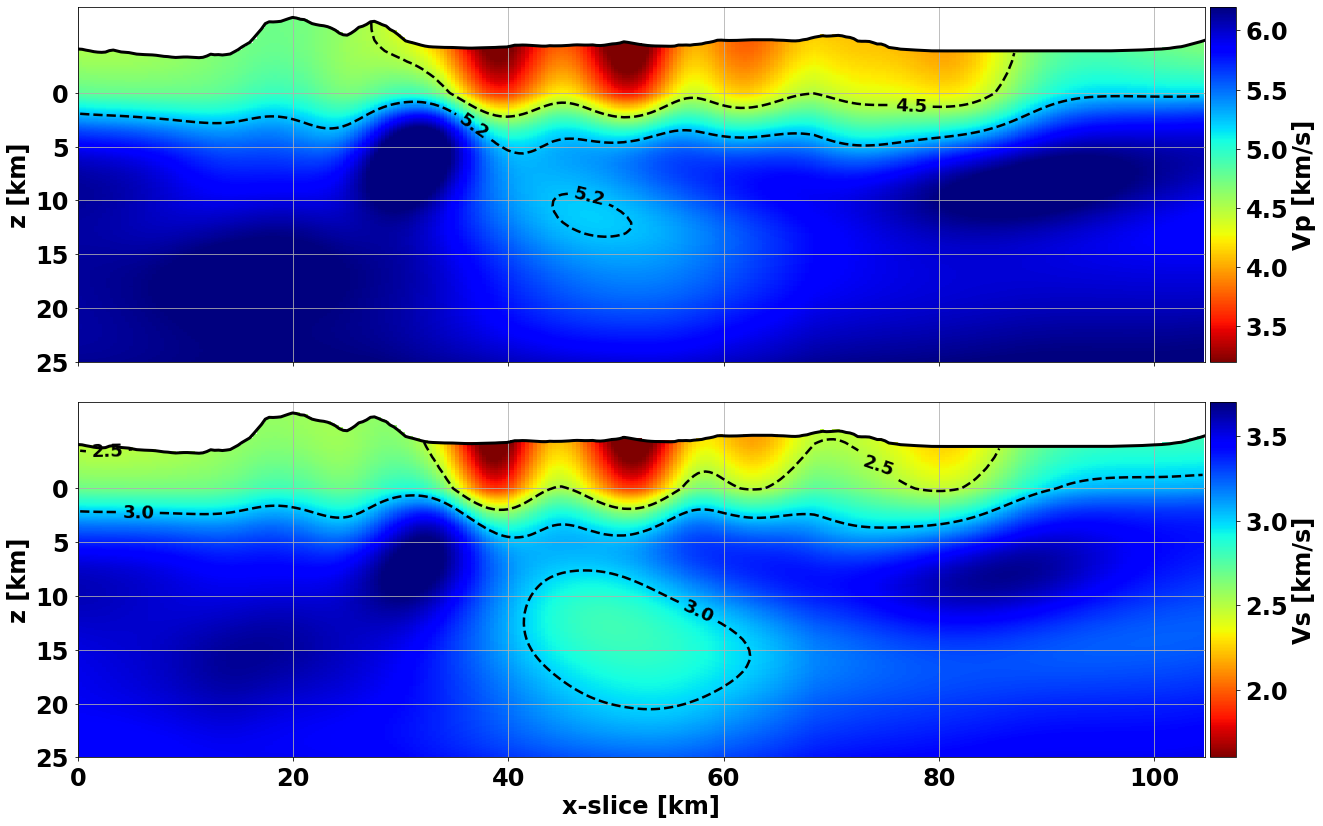

In [126]:
# -------------------------
# Common parameters
# -------------------------
min_x = AxSlice1[0]
max_x = AxSlice1[-1]

max_z = 25.0
idx_z = int(np.floor(((max_z - oz) / dzFineAA) + 0.5))

Vp_slice = Vp_sliceFinalAA[:, :idx_z]
Vs_slice = Vs_sliceFinalAA[:, :idx_z]

# Color limits
vmin_vp = 3.2
vmax_vp = 6.2
vmin_vs = 1.6
vmax_vs = 3.7

extent = [AxSlice1[0], AxSlice1[-1],
          zAxFineAA[idx_z], zAxFineAA[0]]

# -------------------------
# Figure
# -------------------------
fig, (axVp, axVs) = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# ==========================================================
# VS 
# ==========================================================
im_vs = axVs.imshow(
    Vs_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice.T, levels=levels_vs,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(AxSlice1, eleSliceAA, c="k", lw=3)
axVs.set_ylabel("z [km]")
axVs.set_ylim(max_z, eleSliceAA.min() - 0.5)
axVs.set_yscale('function', functions=(utils.forward, utils.inverse))
axVs.grid()

div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=-1.0)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

# ==========================================================
# VP 
# ==========================================================
im_vp = axVp.imshow(
    Vp_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [4.5, 5.25]
cs_vp = axVp.contour(
    Vp_slice.T, levels=levels_vp,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(AxSlice1, eleSliceAA, c="k", lw=3)
axVs.set_xlabel("x-slice [km]")
axVp.set_ylabel("z [km]")
axVp.set_ylim(max_z, eleSliceAA.min() - 0.5)
axVp.set_yscale('function', functions=(utils.forward, utils.inverse))
axVp.grid()

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=-1.0)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

# -------------------------
plt.tight_layout()
plt.show()

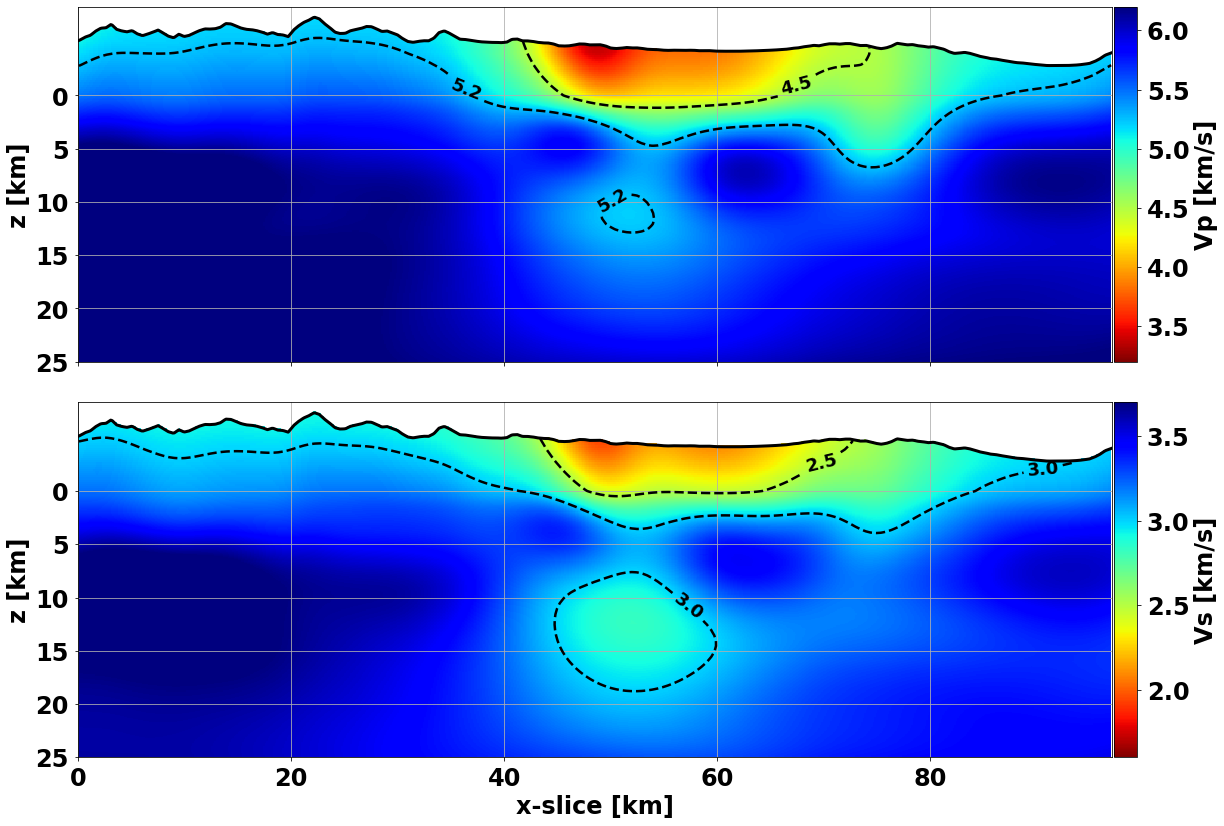

In [128]:
# -------------------------
# Common parameters
# -------------------------
min_x = AxSlice2[0]
max_x = AxSlice2[-1]

max_z = 25.0
idx_z = int(np.floor(((max_z - oz) / dzFineBB) + 0.5))

Vp_slice = Vp_sliceFinalBB[:, :idx_z]
Vs_slice = Vs_sliceFinalBB[:, :idx_z]

# Color limits
vmin_vp = 3.2
vmax_vp = 6.2
vmin_vs = 1.6
vmax_vs = 3.7

extent = [AxSlice2[0], AxSlice2[-1],
          zAxFineBB[idx_z], zAxFineBB[0]]

# -------------------------
# Figure
# -------------------------
fig, (axVp, axVs) = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

# ==========================================================
# VS 
# ==========================================================
im_vs = axVs.imshow(
    Vs_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vs, vmax=vmax_vs,
    aspect=1.0
)

levels_vs = [2.5, 3.0]
cs_vs = axVs.contour(
    Vs_slice.T, levels=levels_vs,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVs.clabel(cs_vs, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVs.plot(AxSlice2, eleSliceBB, c="k", lw=3)
axVs.set_ylabel("z [km]")
axVs.set_ylim(max_z, eleSliceBB.min() - 0.5)
axVs.set_yscale('function', functions=(utils.forward, utils.inverse))
axVs.grid()

div1 = make_axes_locatable(axVs)
cax1 = div1.append_axes("right", size="2%", pad=-1.0)
cb1 = plt.colorbar(im_vs, cax=cax1)
cb1.set_label("Vs [km/s]")

# ==========================================================
# VP 
# ==========================================================
im_vp = axVp.imshow(
    Vp_slice.T, cmap="jet_r",
    extent=extent,
    vmin=vmin_vp, vmax=vmax_vp,
    aspect=1.0
)

levels_vp = [4.5, 5.25]
cs_vp = axVp.contour(
    Vp_slice.T, levels=levels_vp,
    extent=extent,
    origin="upper",
    colors="k", linewidths=2.5, linestyles="--"
)
axVp.clabel(cs_vp, inline=1, fontsize=18, fmt=lambda x: f'{x:.1f}'[-3:])

axVp.plot(AxSlice2, eleSliceBB, c="k", lw=3)
axVs.set_xlabel("x-slice [km]")
axVp.set_ylabel("z [km]")
axVp.set_ylim(max_z, eleSliceBB.min() - 0.5)
axVp.set_yscale('function', functions=(utils.forward, utils.inverse))
axVp.grid()

div2 = make_axes_locatable(axVp)
cax2 = div2.append_axes("right", size="2%", pad=-1.0)
cb2 = plt.colorbar(im_vp, cax=cax2)
cb2.set_label("Vp [km/s]")

# -------------------------
plt.tight_layout()
plt.show()


Try to compute the traveltimes with the inverted or the final models and compare them with the measured arrival times.

In [129]:
### Your code ###

Plot the cross-section of the Vp/Vs ratio for some of the analyzed models. Do you see any interesting structure?

In [ ]:
### Your code ###